# Analysing Openproblems Results

In [27]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns  # optional, just for color if you like
import matplotlib.pyplot as plt

In [58]:
base_dir = "/Users/seohyon/resources/results"

rows = []

# Step 1 — Collect all rows
for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    yaml_path = os.path.join(folder_path, "score_uns.yaml")
    
    if os.path.isdir(folder_path) and os.path.exists(yaml_path):
        with open(yaml_path, "r") as f:
            try:
                data = yaml.safe_load(f)
            except yaml.YAMLError as e:
                print(f"⚠️ Could not read {yaml_path}: {e}")
                continue

        for entry in data:
            metrics = entry.get("metric_ids", [])
            values = entry.get("metric_values", [])
            
            for m_id, m_val in zip(metrics, values):
                rows.append({
                    "dataset_id": entry.get("dataset_id"),
                    "file_size": entry.get("file_size"),
                    "method_id": entry.get("method_id"),
                    "normalization_id": entry.get("normalization_id"),
                    "metric_id": m_id,
                    "metric_value": m_val
                })

# Step 2 — Create one big DataFrame
df = pd.DataFrame(rows)

# # Step 3 — Split into separate tables per dataset_id
# datasets = {}
# for dataset_id, sub_df in df.groupby("dataset_id"):
#     datasets[dataset_id] = sub_df.reset_index(drop=True)
#     print(f"\n=== Dataset: {dataset_id} ===")
#     print(sub_df)

#     # Optional: Save each dataset table as its own CSV
#     safe_name = dataset_id.replace("/", "_")  # clean file name
#     output_path = f"/Users/seohyon/resources/{safe_name}_scores.csv"
#     sub_df.to_csv(output_path, index=False)
#     print(f"✅ Saved to {output_path}")



## Mouse Pancreas

In [29]:
path = "/Users/seohyon/resources/cellxgene_census_mouse_pancreas_atlas_scores.csv"

mouse_pan_df = pd.read_csv(path)

metrics = sorted(mouse_pan_df["metric_id"].unique().tolist())

print("Unique metrics found:")
for m in metrics:
    print("-", m)

Unique metrics found:
- ari
- ari_batch
- asw_batch
- asw_label
- cell_cycle_conservation
- clisi
- graph_connectivity
- hvg_overlap
- ilisi
- isolated_label_asw
- isolated_label_f1
- kbet
- kbet_pg
- kbet_pg_label
- nmi
- nmi_batch
- pcr


I am assuming that higher score indicates better batch mixing

### Barplot for scores per metric

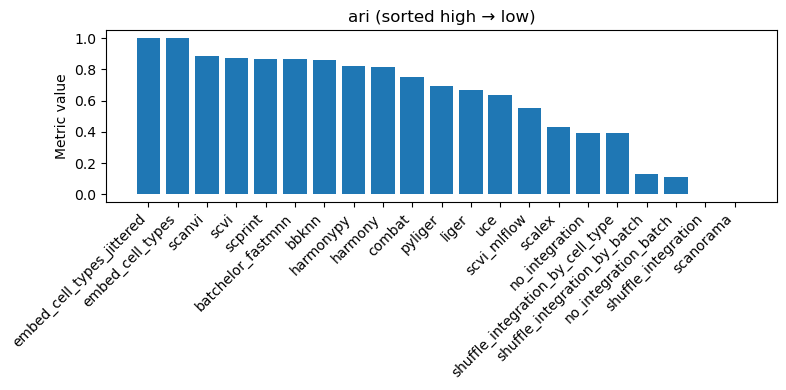

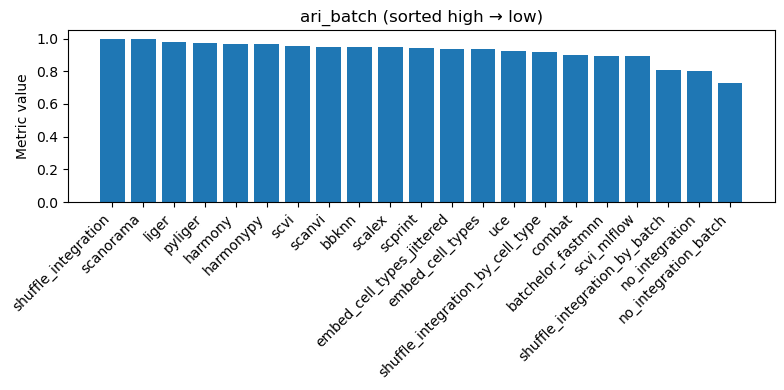

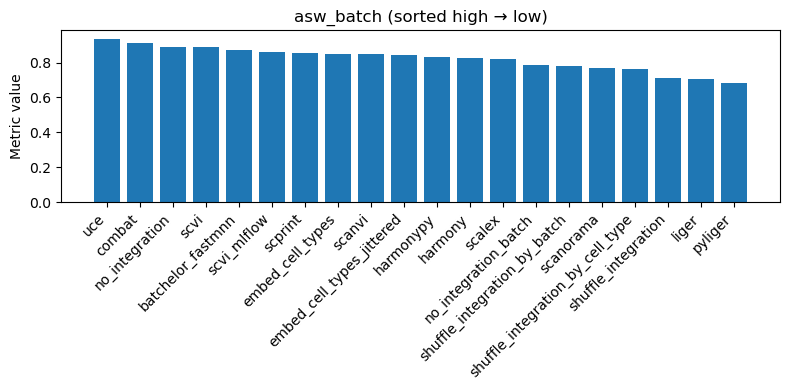

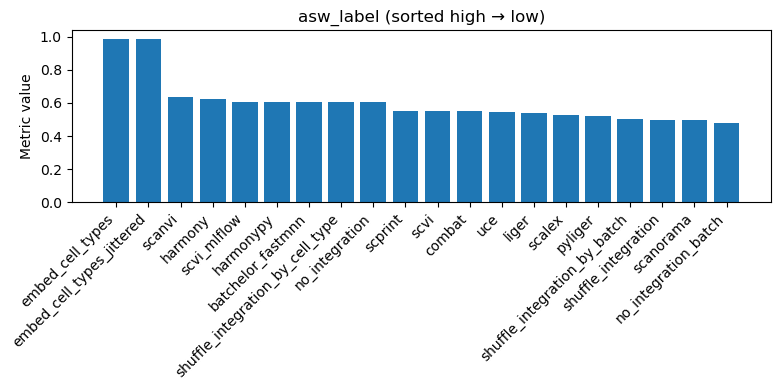

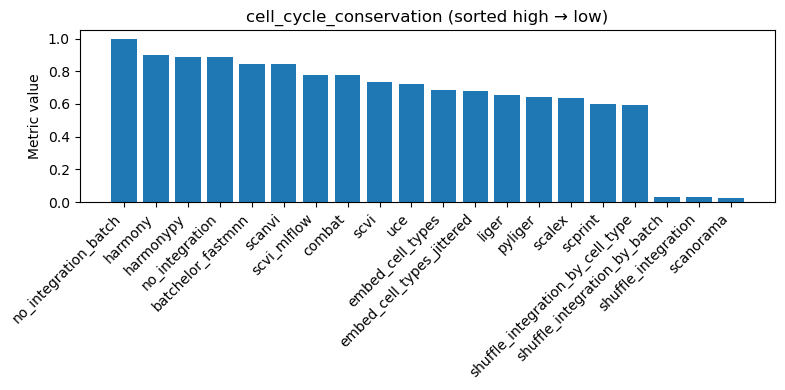

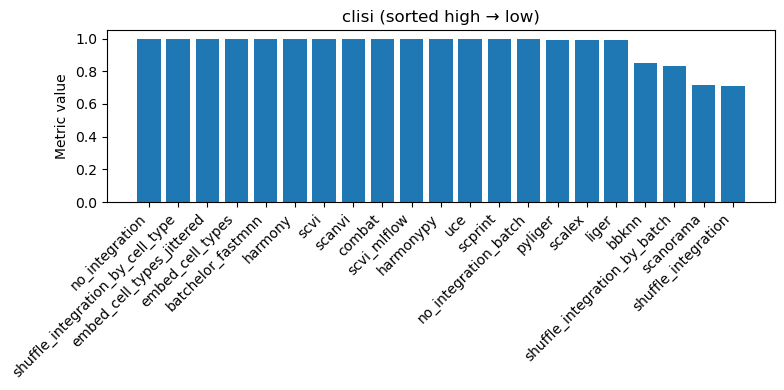

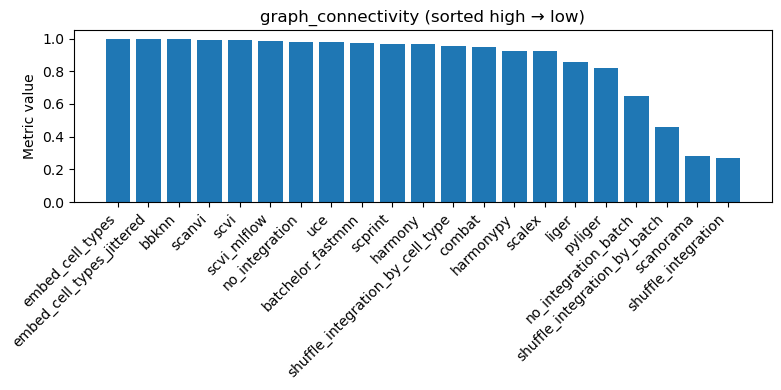

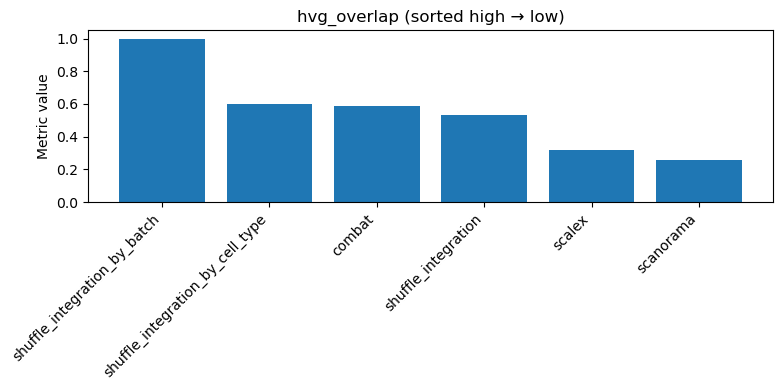

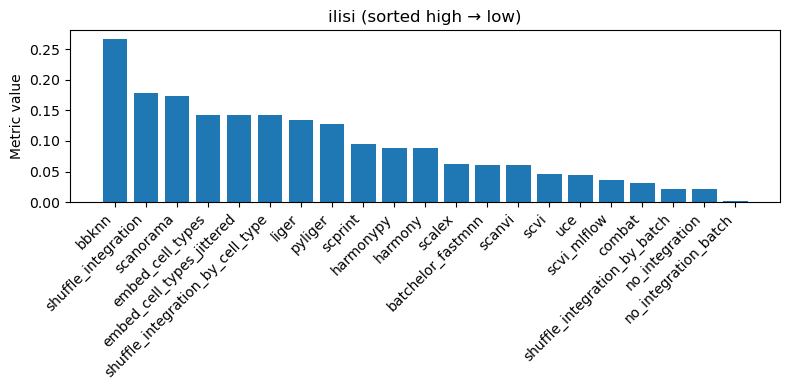

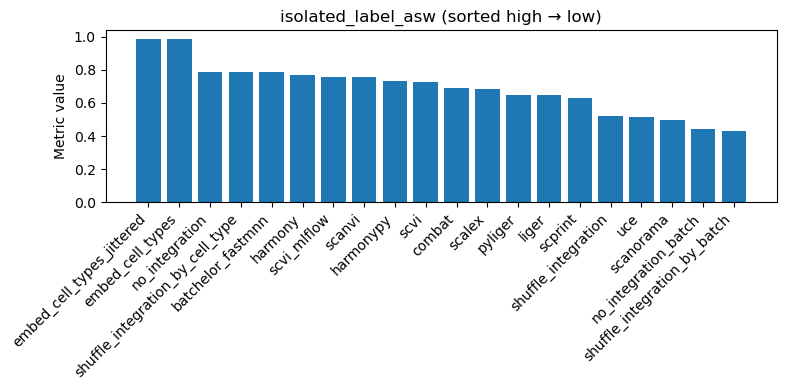

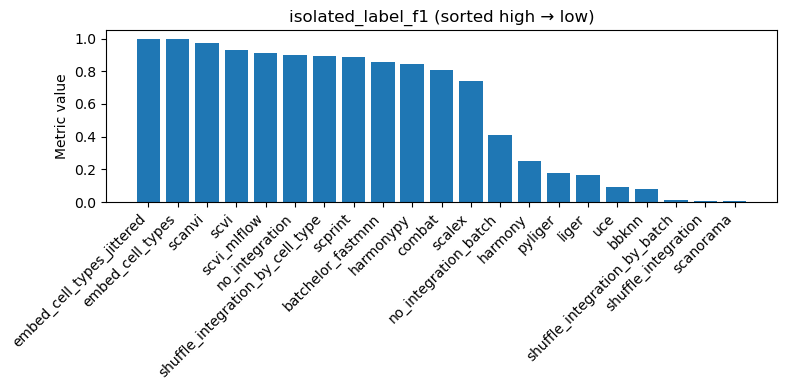

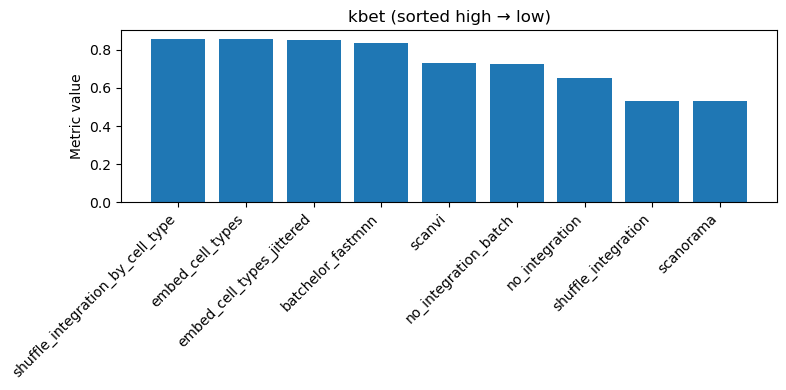

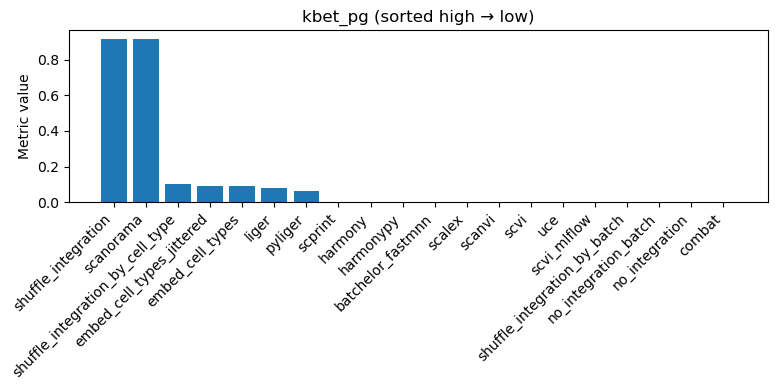

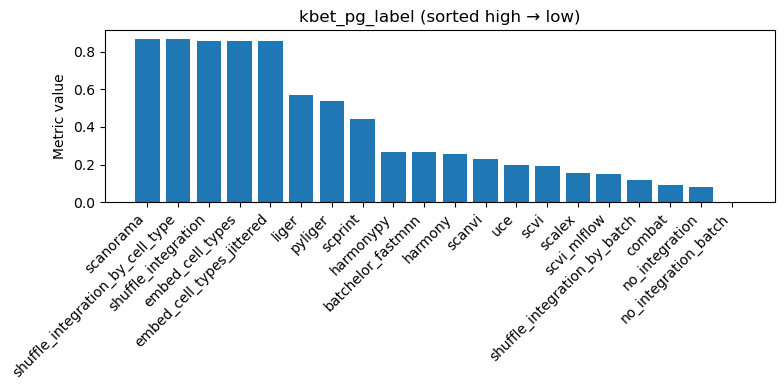

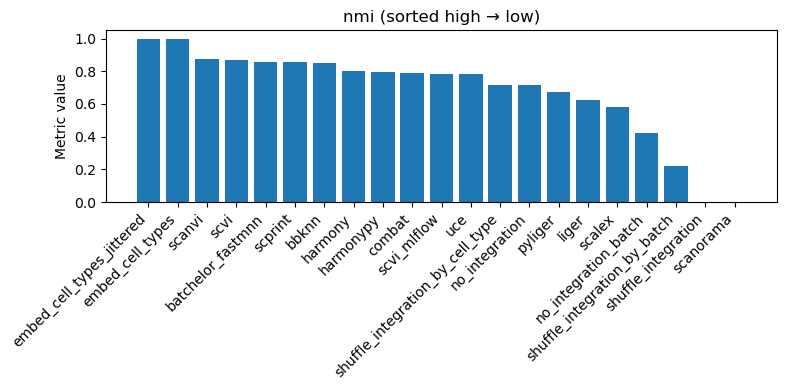

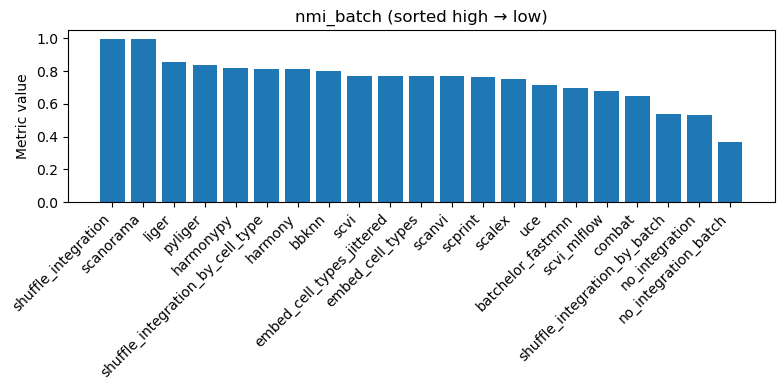

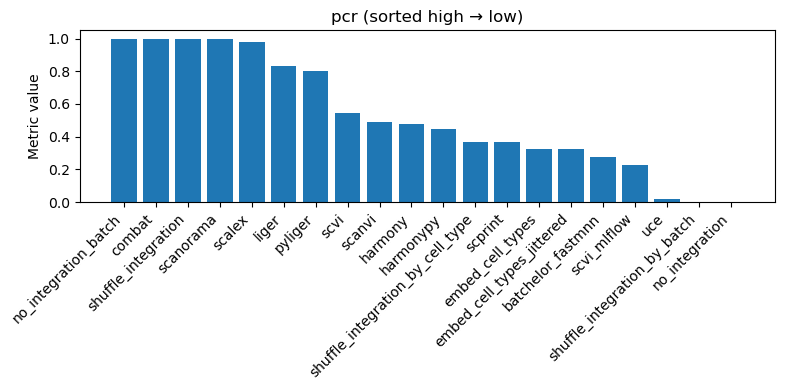

In [30]:
# Loop over each metric
for metric, sub in mouse_pan_df.groupby("metric_id"):
    sub_sorted = sub.sort_values("metric_value", ascending=False)

    plt.figure(figsize=(8, 4))
    plt.bar(sub_sorted["method_id"], sub_sorted["metric_value"])
    plt.title(f"{metric} (sorted high → low)")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Metric value")

    # Save figure per metric
#     safe_metric = metric.replace("/", "_")
#     plt.tight_layout()
#     plt.savefig(f"metric_{safe_metric}.png", dpi=150)
#     plt.close()

    plt.tight_layout()

    plt.show()  # display interactively

# print("✅ All metric bar plots saved as metric_<name>.png")

### Best and Worst Methods

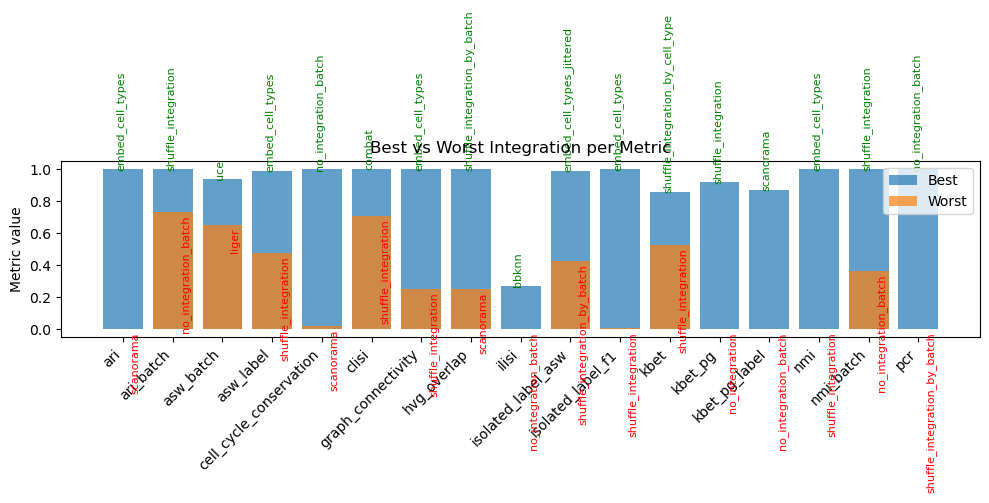

In [32]:
# Find best and worst methods for each metric
best_methods = mouse_pan_df.loc[mouse_pan_df.groupby("metric_id")["metric_value"].idxmax()]
worst_methods = mouse_pan_df.loc[mouse_pan_df.groupby("metric_id")["metric_value"].idxmin()]

plt.figure(figsize=(10, 5))

plt.bar(best_methods["metric_id"], best_methods["metric_value"], label="Best", alpha=0.7)
plt.bar(worst_methods["metric_id"], worst_methods["metric_value"], label="Worst", alpha=0.7)

# Add method names as labels above the bars
for i, (metric, val, method) in enumerate(zip(best_methods["metric_id"], best_methods["metric_value"], best_methods["method_id"])):
    plt.text(i - 0.15, val + 0.01, method, rotation=90, fontsize=8, color="green")

for i, (metric, val, method) in enumerate(zip(worst_methods["metric_id"], worst_methods["metric_value"], worst_methods["method_id"])):
    plt.text(i + 0.15, val - 0.02, method, rotation=90, fontsize=8, color="red", va="top")

# Cosmetics
plt.title("Best vs Worst Integration per Metric")
plt.ylabel("Metric value")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Thoughts: ASW_batch has high metric scores for all of the methods. Let's look into no_integration_batch - this one is not integrated by batch but still got almost 0.8 with ASW_batch. Is ASW_batch reliable?

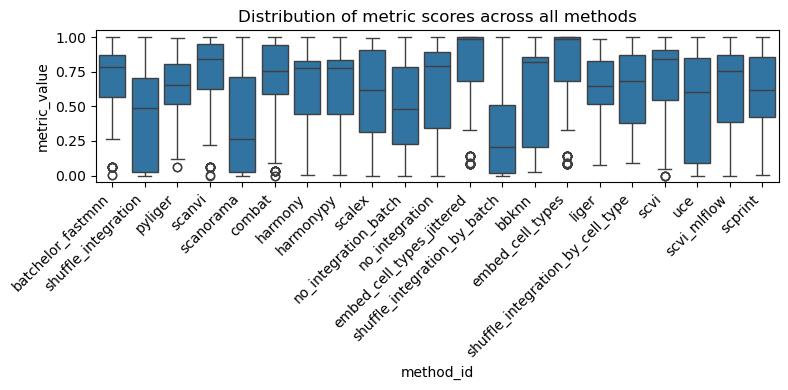

In [33]:
plt.figure(figsize=(8,4))
sns.boxplot(x="method_id", y="metric_value", data=mouse_pan_df)
plt.title("Distribution of metric scores across all methods")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Can we trust the metrics? Without knowing every detail about each metrics?
=> box plot per metric would be better (switch the axes), look separately per datasets as well

### Adding dataset characteristics to the big df

In [59]:
meta = pd.read_csv("/Users/seohyon/resources/Batch_Integration_Dataset - Tabellenblatt2.csv")
df["dataset_id"] = df["dataset_id"].str.split("/").str[-1] # make them the same name to merge
df = pd.merge(df, meta, left_on="dataset_id", right_on="dataset", how="inner").drop(columns=["dataset"])

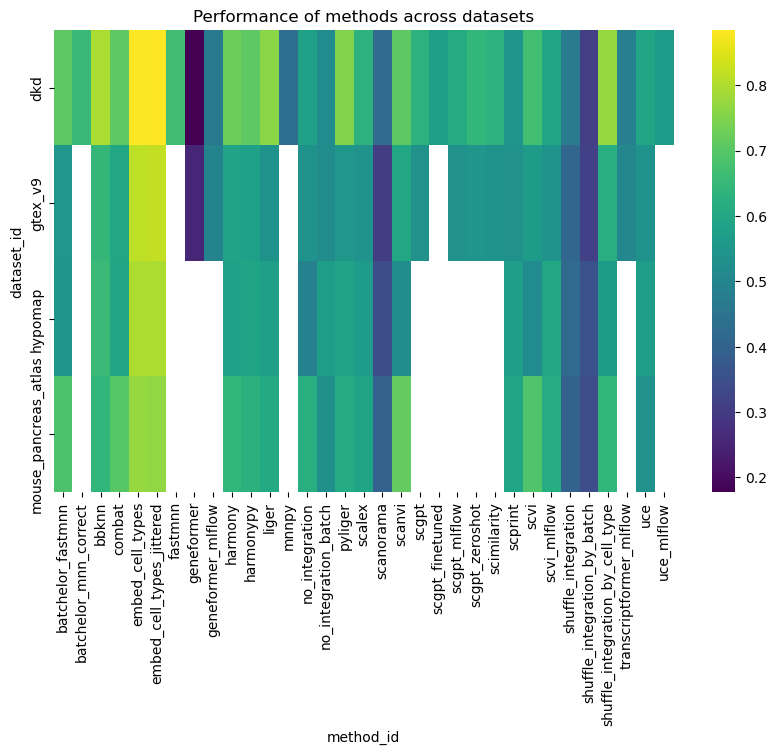

In [60]:
pv = df.pivot_table(index="dataset_id", columns="method_id", values="metric_value", aggfunc="mean")
plt.figure(figsize=(10, 6))
sns.heatmap(pv, cmap="viridis", annot=False)
plt.title("Performance of methods across datasets")
plt.yticks(rotation=90) # bro why u don't work
plt.show()

check why some are missing (white) - if the data is missing, what do we want to do with them?

### Metric dependence on dataset characteristics

<Axes: >

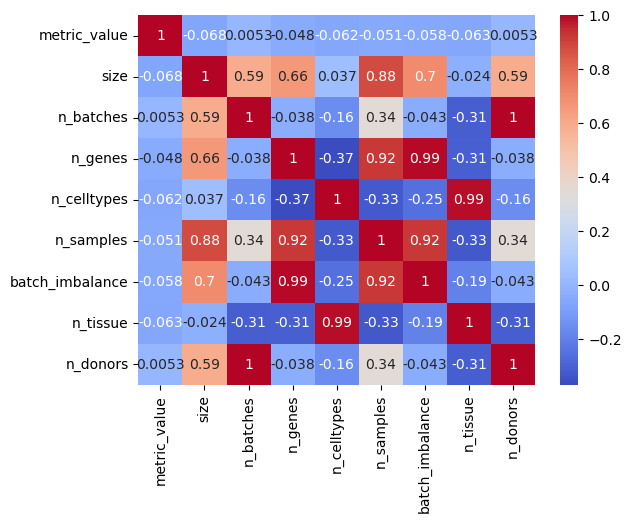

In [63]:
num_cols = ["metric_value","size","n_batches","n_genes","n_celltypes","n_samples","batch_imbalance","n_tissue","n_donors"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")

so... kind of.. around 0 with metric value.. no correlation?

Adjust to be around 0

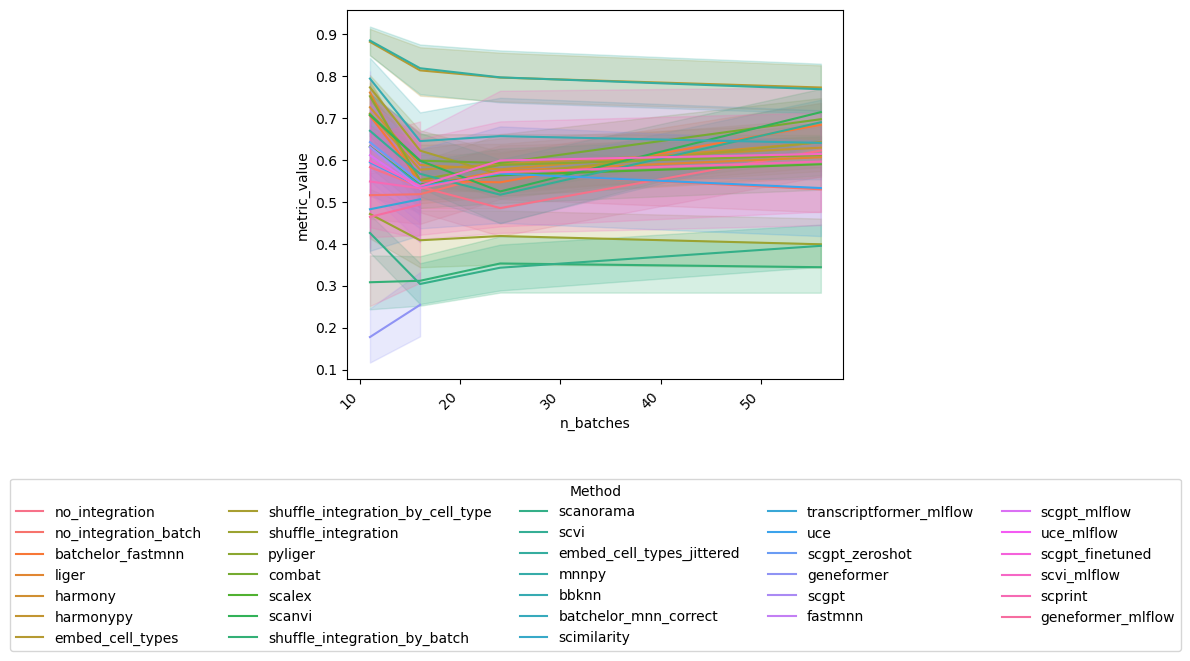

In [55]:
sns.lineplot(x="n_batches", y="metric_value", hue="method_id", data=df, estimator="mean")

plt.legend(
    bbox_to_anchor=(0.5, -0.25),  # center below the plot
    loc='upper center',
    ncol=5,                       # number of columns — adjust based on number of methods
    title="Method"
)
plt.xticks(rotation=45, ha="right")
plt.show()

=> separate plot per metric or color by metric instead of method

In [64]:
df["nested_batches"] = (
    df["nested_batches"]
    .fillna("Unknown")            # replace NaN with "Unknown"
    .astype(str)                  # ensure string
    .str.capitalize()             # make it 'Yes', 'No', 'Unknown'
)

/var/folders/hn/2jsgf5g54l9glw98f7345cb00000gn/T/ipykernel_43574/413931212.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="nested_batches", y="metric_value", data=df, palette="Set2")


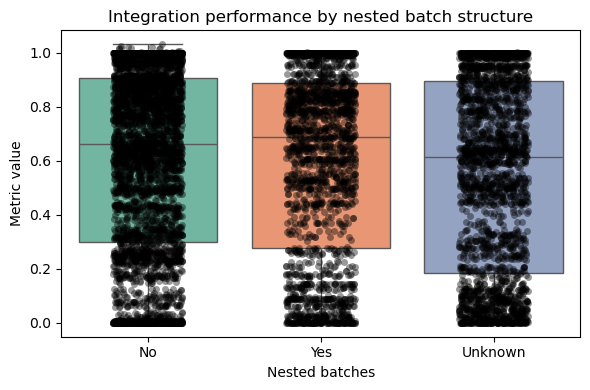

In [67]:
plt.figure(figsize=(6,4))
sns.boxplot(x="nested_batches", y="metric_value", data=df, palette="Set2")
sns.stripplot(x="nested_batches", y="metric_value", data=df, color="black", alpha=0.4, jitter=0.2)
plt.title("Integration performance by nested batch structure")
plt.xlabel("Nested batches")
plt.ylabel("Metric value")
plt.tight_layout()
plt.show()


=> per metric.. maybe scatter

do a lot of plots per metric

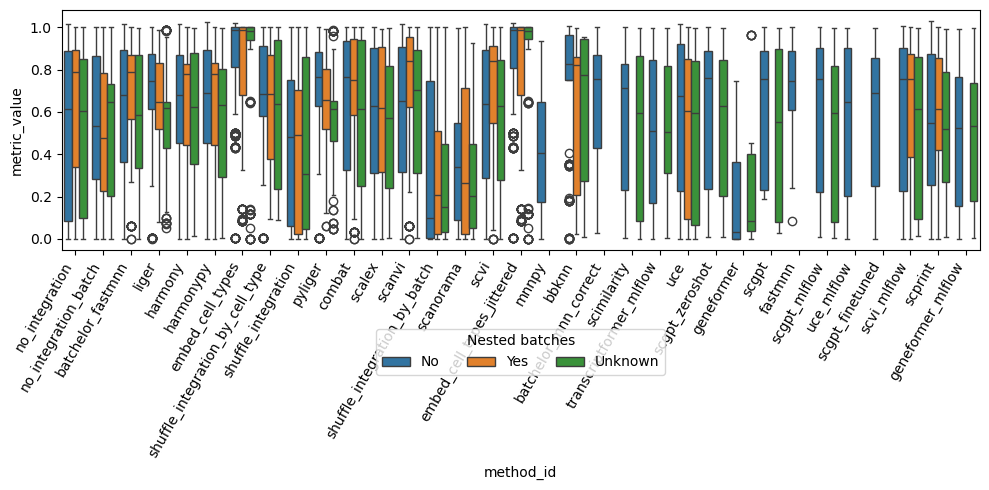

In [66]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="method_id", y="metric_value", hue="nested_batches", data=df)
plt.xticks(rotation=60, ha="right")

plt.legend(
    title="Nested batches",
    bbox_to_anchor=(0.5, -0.3), loc="upper center",
    ncol=3  # spread the legend horizontally
)
plt.tight_layout()
plt.show()


### Performance per Organism

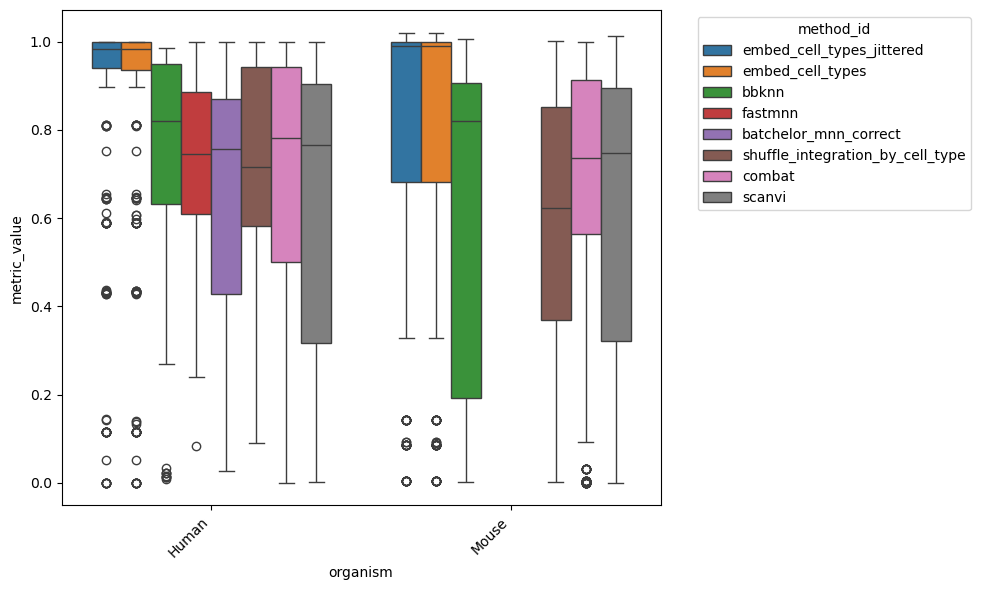

In [47]:
# Compute average metric per method to order them
order = df.groupby("method_id")["metric_value"].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(
    x="organism", y="metric_value", hue="method_id",
    data=df, order=None, hue_order=order[:8]  # show only top 8 methods
)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="method_id")
plt.tight_layout()
plt.show()

Note that fastmnn and batchelor_mnn_correct do not perform well in Mouse